# Visualisasi Validasi — Fase 4 Query Development

Notebook ini membaca hasil export CSV dari tiap query di `sql/03-06_*.sql`, lalu membuat chart validasi untuk masing-masing business question.

## Cara Export dari DBeaver
Setelah jalankan satu blok query (Ctrl+Enter), klik kanan di grid hasil (Result Set) → **Export Resultset** → pilih format **CSV** → simpan dengan nama file PERSIS seperti tabel di bawah, ke folder `data/processed/`.

| Business Question | Nama File Export |
|---|---|
| Q1 — RFM (semua kolom, per pelanggan) | `q1_rfm.csv` |
| Q2 — One-time vs repeat buyer | `q2_buyer_type.csv` |
| Q3 — Tren revenue bulanan | `q3_monthly_revenue.csv` |
| Q5 (bagian musiman) — revenue per bulan kalender | `q5_seasonality.csv` |
| Q4 — Growth kategori 2017 vs 2018 | `q4_category_growth.csv` |
| Q6b — Status churn per pelanggan | `q6b_churn_status.csv` |
| Q7 — Review score per status churn | `q7_review_churn.csv` |
| Q8 — Kategori top per state | `q8_category_per_state.csv` |
| Q9 — Revenue per state | `q9_revenue_per_state.csv` |

(Q6a dilewati — hasilnya cuma 1 angka, tidak perlu chart.)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("../data/processed")
plt.rcParams["figure.figsize"] = (8, 5)

## Q1-Distribusi Segmen RFM

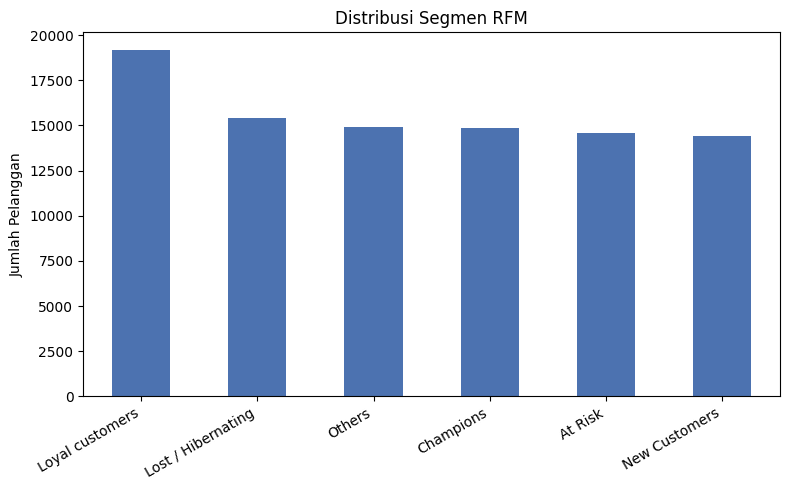

In [2]:
df_q1 = pd.read_csv(processed_dir / "q1_rfm.csv")
segment_counts = df_q1["rfm_segment"].value_counts()

plt.figure()
segment_counts.plot(kind="bar", color="#4C72B0")
plt.title("Distribusi Segmen RFM")
plt.ylabel("Jumlah Pelanggan")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Q2-Kontribusi Revenue: One-time vs Repeat Buyer

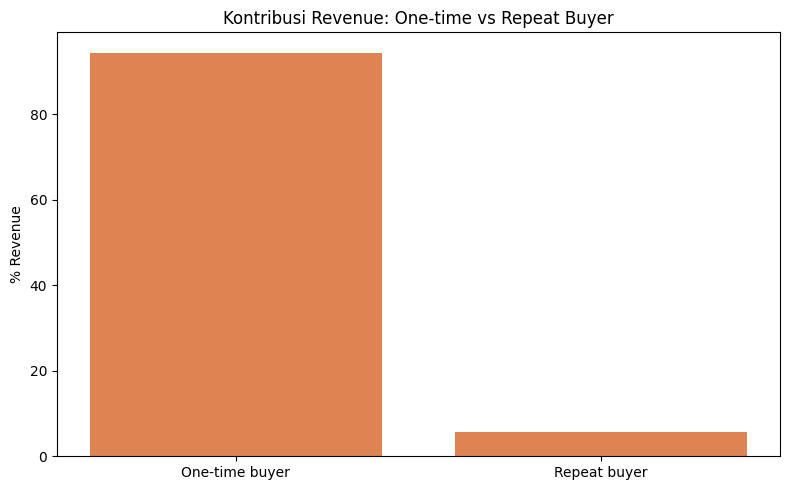

In [3]:
df_q2 = pd.read_csv(processed_dir / "q2_buyer_type.csv")

plt.figure()
plt.bar(df_q2["customer_type"], df_q2["pct_revenue"], color="#DD8452")
plt.title("Kontribusi Revenue: One-time vs Repeat Buyer")
plt.ylabel("% Revenue")
plt.tight_layout()
plt.show()

## Q3-Tren Revenue Bulanan

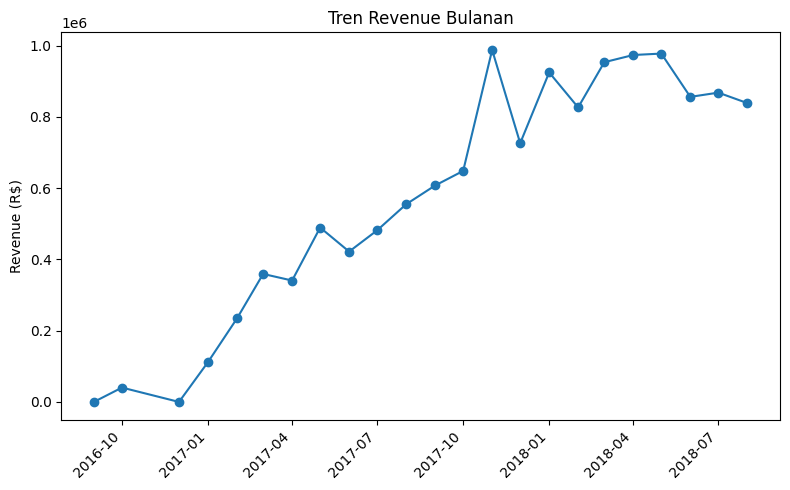

In [4]:
df_q3 = pd.read_csv(processed_dir/"q3_monthly_revenue.csv", parse_dates=["bulan"])
df_q3 = df_q3.sort_values("bulan")

plt.figure()
plt.plot(df_q3["bulan"], df_q3["revenue"], marker="o")
plt.title("Tren Revenue Bulanan")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Q5-Pola Musiman (per Bulan Kalender)

**Ingat:** ini bukan pola musiman asli, ada artifact keterbatasan cakupan data (Sep-Des cuma 1 tahun data, Jan-Agu 2 tahun) — lihat catatan di `fase4_query_development.md`.

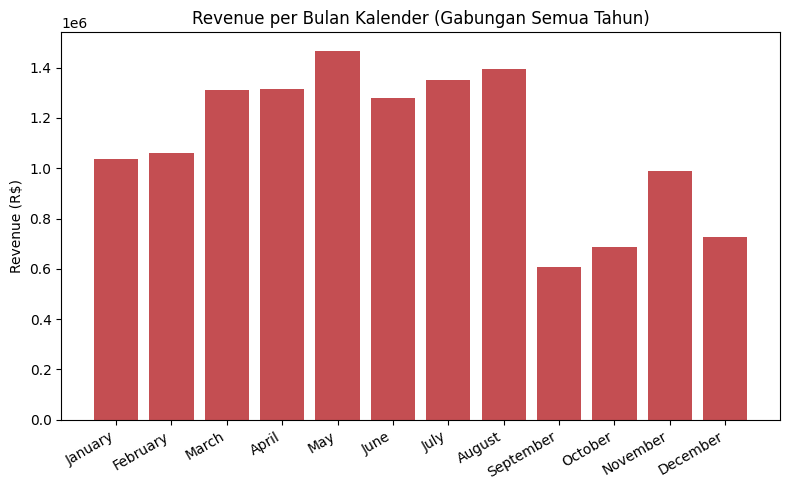

In [5]:
df_q5 = pd.read_csv(processed_dir / "q5_seasonality.csv")
df_q5 = df_q5.sort_values("bulan_ke")

plt.figure()
plt.bar(df_q5["nama_bulan"].str.strip(), df_q5["total_revenue"], color="#C44E52")
plt.title("Revenue per Bulan Kalender (Gabungan Semua Tahun)")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Q4-Top 5 Kategori Growth Tertinggi

**Ingat:** cek dulu `revenue_2017` di data mentahnya — growth % besar dari base kecil bisa menyesatkan.

                                category  revenue_2017  revenue_2018  \
0  small_appliances_home_oven_and_coffee        734.79      45854.77   
1                    diapers_and_hygiene         76.00       1289.89   
2                  arts_and_craftmanship        151.89       1662.12   
3              construction_tools_lights       4053.48      35903.52   
4                             cine_photo        695.00       5979.47   

   growth_pct  
0     6140.53  
1     1597.22  
2      994.29  
3      785.75  
4      760.36  


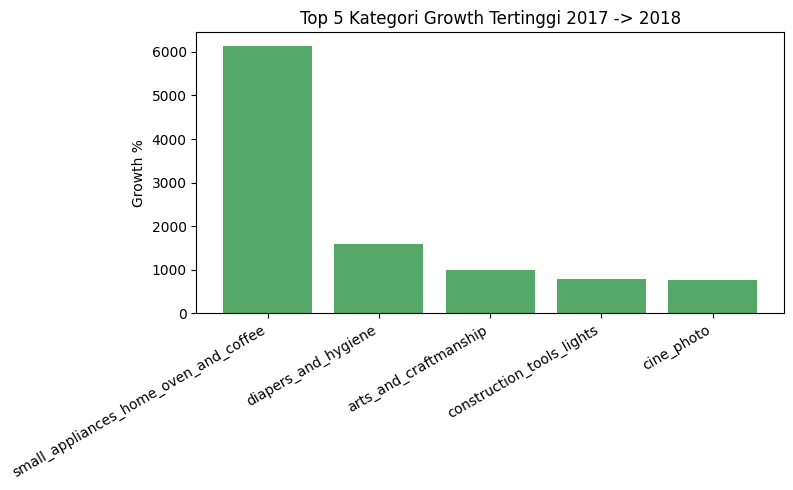

In [6]:
df_q4 = pd.read_csv(processed_dir / "q4_category_growth.csv")
top5 = df_q4.sort_values("growth_pct", ascending=False).head(5)

print(top5[["category", "revenue_2017", "revenue_2018", "growth_pct"]])

plt.figure()
plt.bar(top5["category"], top5["growth_pct"], color="#55A868")
plt.title("Top 5 Kategori Growth Tertinggi 2017 -> 2018")
plt.ylabel("Growth %")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Q6b-Distribusi Status Churn

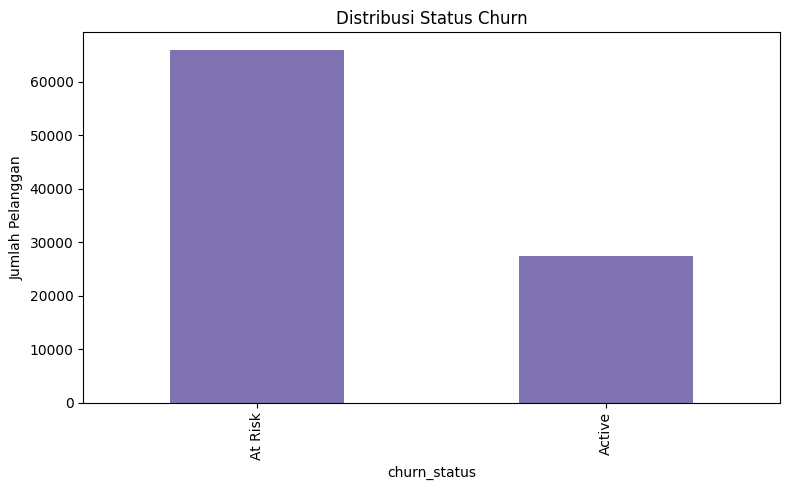

In [3]:
df_q6b = pd.read_csv(processed_dir / "q6b_churn_status.csv")
status_counts = df_q6b["churn_status"].value_counts()

plt.figure()
status_counts.plot(kind="bar", color="#8172B2")
plt.title("Distribusi Status Churn")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

## Q7-Review Score Vs Status Churn

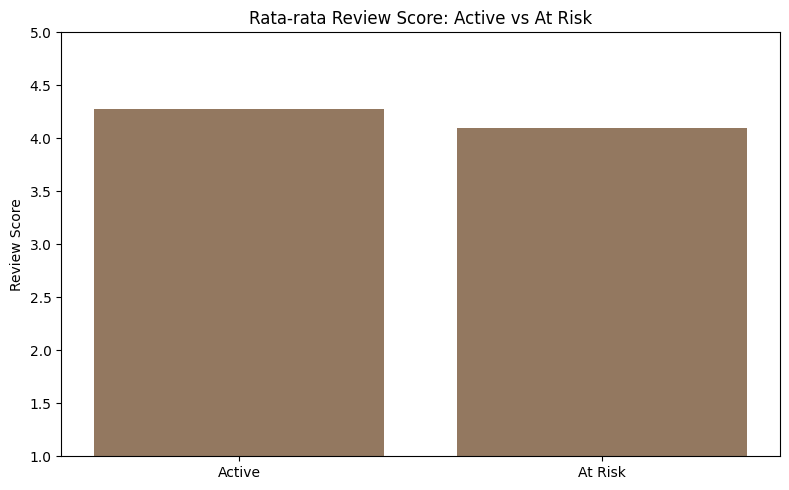

In [5]:
df_q7 = pd.read_csv(processed_dir / "q7_review_churn.csv")

plt.figure()
plt.bar(df_q7["churn_status"], df_q7["rata_rata_reviews_score"], color="#937860")
plt.title("Rata-rata Review Score: Active vs At Risk")
plt.ylabel("Review Score")
plt.ylim(1, 5)
plt.tight_layout()
plt.show()